<a href="https://colab.research.google.com/github/JCF-the-creator/GoogleColabGeneration/blob/main/Atividade_ETL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
!pip install plotly

In [71]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

df_hotel_messy = pd.read_csv('/content/hotel_dataset_messy.csv')

In [72]:
df_hotel_messy['Guest_Name'] = df_hotel_messy['Guest_Name'].str.title()

df_hotel_messy['CheckIn_Date'] = pd.to_datetime(df_hotel_messy['CheckIn_Date'])
df_hotel_messy['CheckOut_Date'] = pd.to_datetime(df_hotel_messy['CheckOut_Date'])

for i in df_hotel_messy['Total_Charges']:
  if i < 0:
    df_hotel_messy['Total_Charges'] = df_hotel_messy['Total_Charges'].replace(i, i*-1)

df_hotel_messy['Days_Stays'] = (df_hotel_messy['CheckOut_Date'] - df_hotel_messy['CheckIn_Date']).dt.days

In [73]:
display(df_hotel_messy)
df_hotel_messy.info()

,Guest_Name,Age,Room_Type,CheckIn_Date,CheckOut_Date,Booking_Channel,Total_Charges,Satisfaction_Score,Days_Stays
0,Paulo Chiavini,69,Standard,2025-08-21,2025-08-23,Site Oficial,296.967888,1.0,2
1,Ana Pereira,32,Standard,2025-08-28,2025-09-10,Booking.com,2235.383385,5.0,13
2,Luyz Silva,78,Standard,2025-01-04,2025-01-18,Site Oficial,1907.702878,4.0,14
3,Luyz Silva,38,Deluxe,2025-06-30,2025-07-14,Booking.com,3751.333568,2.0,14
4,Ana Silva,41,Deluxe,2025-02-28,2025-03-02,Booking.com,575.659560,3.0,2
...,...,...,...,...,...,...,...,...,...
1495,Fernanda Silva,37,Suite,2025-07-24,2025-07-31,Agencia,2807.198658,4.0,7
1496,Joao Santos,25,Deluxe,2025-05-18,2025-05-23,Booking.com,1196.424311,3.0,5
1497,Felipe Costa,60,Standard,2025-11-09,2025-11-12,Site Oficial,459.981567,1.0,3
1498,Fernanda Okawachi,18,Standard,2025-10-26,2025-10-27,Agencia,140.124279,2.0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Guest_Name          1500 non-null   object        
 1   Age                 1500 non-null   int64         
 2   Room_Type           1500 non-null   object        
 3   CheckIn_Date        1500 non-null   datetime64[ns]
 4   CheckOut_Date       1500 non-null   datetime64[ns]
 5   Booking_Channel     1500 non-null   object        
 6   Total_Charges       1500 non-null   float64       
 7   Satisfaction_Score  1366 non-null   float64       
 8   Days_Stays          1500 non-null   int64         
dtypes: datetime64[ns](2), float64(2), int64(2), object(3)
memory usage: 105.6+ KB


<Axes: xlabel='Room_Type', ylabel='count'>

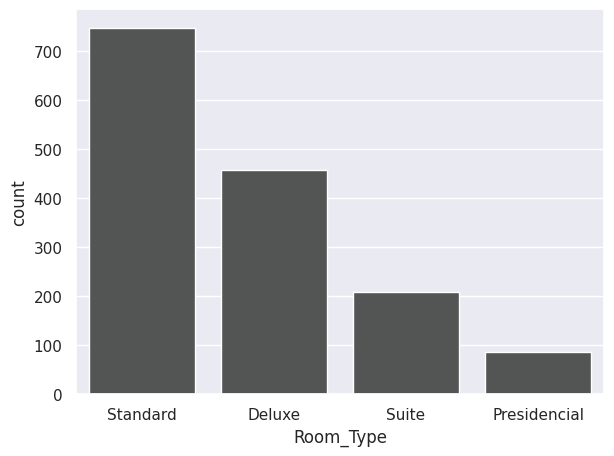

In [74]:
# configurar o estilo dos graficos
sns.set_theme(style='darkgrid')
plt.figure(figsize=(15,5))


plt.subplot(1,2,1)
sns.countplot(data=df_hotel_messy,
    x='Room_Type',
    order=df_hotel_messy['Room_Type'].value_counts().index,
    color='#515654')


In [75]:
# --- Limpeza rápida (Garantindo que os dados estão prontos) ---
# Remove linhas onde um dos dois campos esteja vazio
df_clean = df_hotel_messy.dropna(subset=['Room_Type', 'Satisfaction_Score','Total_Charges', 'Days_Stays']).copy()

df_grouped = df_clean.groupby('Room_Type')['Satisfaction_Score'].mean().reset_index()

fig_bar = px.bar(
    df_grouped,
    x='Room_Type',
    y='Satisfaction_Score',
    title='Média de Satisfação por Tipo de Quarto',
    labels={'Room_Type': 'Tipo de Quarto', 'Satisfaction_Score': 'Média do Score'},
    color='Room_Type',
    template='plotly_white'
)

# Ajustando o eixo Y para começar do zero de forma clara
fig_bar.update_layout(yaxis_range=[0, df_grouped['Satisfaction_Score'].max() * 1.1])

fig_bar.show()

In [78]:
# Força a conversão para numérico (o 'coerce' transforma textos inválidos em NaN)
df_clean['Total_Charges'] = pd.to_numeric(df_clean['Total_Charges'], errors='coerce')
df_clean['Days_Stays'] = pd.to_numeric(df_clean['Days_Stays'], errors='coerce')

# Remove as linhas que falharam na conversão numérica
df_clean = df_clean.dropna(subset=['Total_Charges', 'Days_Stays'])

# --- Criando o Scatter Plot ---
fig = px.scatter(
    df_clean,
    x='Days_Stays',
    y='Total_Charges',
    title='Relação entre Dias de Estadia e Gasto Total',
    labels={'Days_Stays': 'Dias de Estadia (Days Stays)', 'Total_Charges': 'Total Gasto ($)'},
    trendline='ols',          # Opcional: Adiciona uma linha de tendência (regressão linear)
    template='plotly_white',
    opacity=0.5               # Opacidade menor ajuda a ver pontos sobrepostos
)

# Customizando o tamanho e aparência dos pontos
fig.update_traces(marker=dict(size=8, line=dict(width=0.5, color='DarkSlateGrey')))

fig.show()